# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Load Datasets

In [3]:
sales = pd.read_csv("../datasets/data warehouse/dw_fact_sales.csv")

products = pd.read_csv("../datasets/data warehouse/dw_dim_product.csv")

stores = pd.read_csv("../datasets/data warehouse/dw_dim_store.csv")

shelf = pd.read_csv("../datasets/data warehouse/dw_fact_shelf_audit.csv")

# Dataset Shapes

In [4]:
print("Sales Shape:", sales.shape)
print("Products Shape:", products.shape)
print("Stores Shape:", stores.shape)
print("Shelf Audit Shape:", shelf.shape)

Sales Shape: (100000, 6)
Products Shape: (500, 5)
Stores Shape: (50, 6)
Shelf Audit Shape: (25000, 7)


# First Five Records

In [5]:
sales.head()

,transaction_id,transaction_date,store_id,sku_id,quantity_sold,sales_amount
0,T0000001,2025-12-10,S039,SKU0206,7,3200.75
1,T0000002,2025-05-01,S036,SKU0141,1,260.51
2,T0000003,2025-03-15,S005,SKU0155,8,1210.80
3,T0000004,2025-10-06,S041,SKU0375,2,399.30
4,T0000005,2025-08-11,S036,SKU0130,7,792.75


In [6]:
products.head()

,sku_id,product_name,brand,category,unit_price
0,SKU0256,Lizol Product 256,Lizol,Household,21.78
1,SKU0192,Harpic Product 192,Harpic,Household,209.95
2,SKU0123,Nivea Product 123,Nivea,Personal Care,421.03
3,SKU0096,Doritos Product 96,Doritos,Snacks,60.11
4,SKU0272,Modern Product 272,Modern,Bakery,170.44


In [7]:
stores.head()

,store_id,store_name,city,state,region,store_size
0,S010,RetailMart Jaipur-10,Jaipur,Rajasthan,North,Small
1,S003,RetailMart Kolkata-3,Kolkata,West Bengal,East,Large
2,S013,RetailMart Bangalore-13,Bangalore,Karnataka,South,Medium
3,S029,RetailMart Lucknow-29,Lucknow,Uttar Pradesh,North,Small
4,S001,RetailMart Lucknow-1,Lucknow,Uttar Pradesh,North,Large


In [8]:
shelf.head()

,audit_id,audit_date,store_id,sku_id,visibility_score,shelf_compliance,audit_issue
0,AUD000001,2026-06-01,S001,SKU0001,89.74,Compliant,NaN
1,AUD000002,2026-06-01,S001,SKU0002,73.91,Compliant,NaN
2,AUD000003,2026-06-01,S001,SKU0003,43.75,Non-Compliant,Low Visibility
3,AUD000004,2026-06-01,S001,SKU0004,19.05,Non-Compliant,Low Visibility
4,AUD000005,2026-06-01,S001,SKU0005,72.73,Compliant,NaN


# Dataset Information

In [9]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  str    
 1   transaction_date  100000 non-null  str    
 2   store_id          100000 non-null  str    
 3   sku_id            100000 non-null  str    
 4   quantity_sold     100000 non-null  int64  
 5   sales_amount      100000 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 4.6 MB


In [10]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku_id        500 non-null    str    
 1   product_name  500 non-null    str    
 2   brand         500 non-null    str    
 3   category      500 non-null    str    
 4   unit_price    500 non-null    float64
dtypes: float64(1), str(4)
memory usage: 19.7 KB


In [11]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    50 non-null     str  
 1   store_name  50 non-null     str  
 2   city        50 non-null     str  
 3   state       50 non-null     str  
 4   region      50 non-null     str  
 5   store_size  50 non-null     str  
dtypes: str(6)
memory usage: 2.5 KB


In [12]:
shelf.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   audit_id          25000 non-null  str    
 1   audit_date        25000 non-null  str    
 2   store_id          25000 non-null  str    
 3   sku_id            25000 non-null  str    
 4   visibility_score  25000 non-null  float64
 5   shelf_compliance  25000 non-null  str    
 6   audit_issue       9569 non-null   str    
dtypes: float64(1), str(6)
memory usage: 1.3 MB


# Missing Values

In [13]:
sales.isnull().sum()

transaction_id      0
transaction_date    0
store_id            0
sku_id              0
quantity_sold       0
sales_amount        0
dtype: int64

In [14]:
products.isnull().sum()

sku_id          0
product_name    0
brand           0
category        0
unit_price      0
dtype: int64

In [15]:
stores.isnull().sum()

store_id      0
store_name    0
city          0
state         0
region        0
store_size    0
dtype: int64

In [16]:
shelf.isnull().sum()

audit_id                0
audit_date              0
store_id                0
sku_id                  0
visibility_score        0
shelf_compliance        0
audit_issue         15431
dtype: int64

# Duplicate Records

In [17]:
print("Sales Duplicates:", sales.duplicated().sum())
print("Products Duplicates:", products.duplicated().sum())
print("Stores Duplicates:", stores.duplicated().sum())
print("Shelf Duplicates:", shelf.duplicated().sum())

Sales Duplicates: 0
Products Duplicates: 0
Stores Duplicates: 0
Shelf Duplicates: 0


# Statistical Summary

In [18]:
sales.describe()

,quantity_sold,sales_amount
count,100000.00000,100000.000000
mean,5.49686,1421.867094
std,2.87087,1135.618969
min,1.00000,20.450000
25%,3.00000,470.380000
50%,5.00000,1101.690000
75%,8.00000,2116.710000
max,10.00000,4996.800000


In [19]:
shelf.describe()

,visibility_score
count,25000.000000
mean,57.262143
std,29.769178
min,0.000000
25%,38.100000
50%,61.110000
75%,81.820000
max,100.000000


# Revenue Distribution

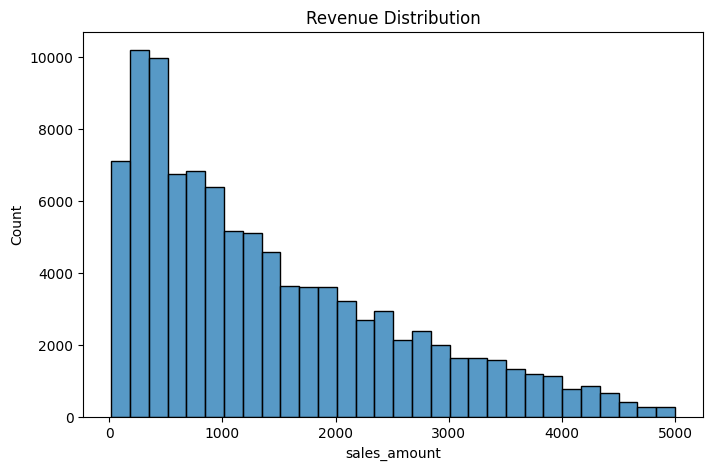

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(sales['sales_amount'], bins=30)
plt.title("Revenue Distribution")
plt.show()

# Top Categories

In [21]:
products['category'].value_counts()

category
Snacks           99
Household        92
Personal Care    84
Dairy            77
Bakery           74
Beverages        74
Name: count, dtype: int64

# Store Distribution

In [22]:
stores['region'].value_counts()

region
West     17
North    14
South    12
East      7
Name: count, dtype: int64

# Shelf Compliance Distribution

In [23]:
shelf['shelf_compliance'].value_counts()

shelf_compliance
Compliant        15431
Non-Compliant     9569
Name: count, dtype: int64

# Key Findings

- Data successfully loaded.
- No major missing values detected.
- Revenue data available for business analysis.
- Shelf audit records available for compliance analysis.
- Store and product dimensions ready for warehouse analytics.